--- Data Preparation ---
Training set shape: (350, 2)
Test set shape: (150, 2)

--- Model Training ---
Model training complete.

--- Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86        73
           1       0.85      0.92      0.88        77

    accuracy                           0.87       150
   macro avg       0.88      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150



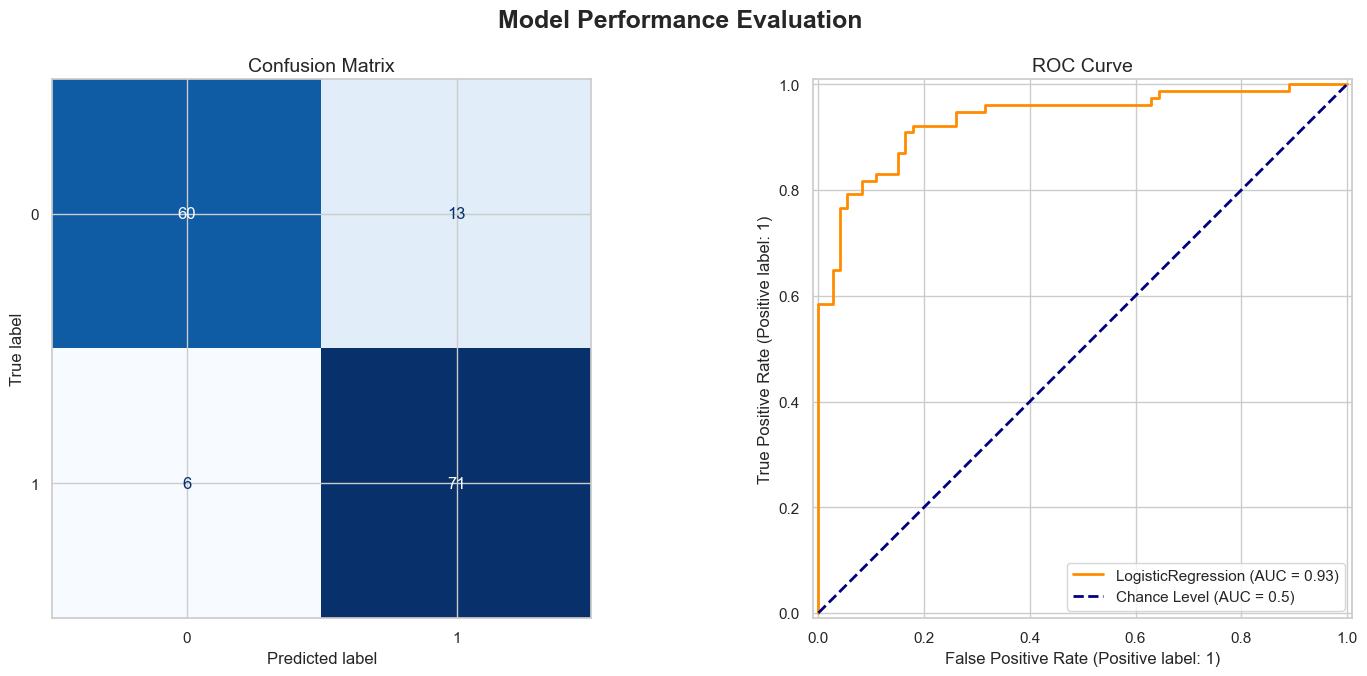

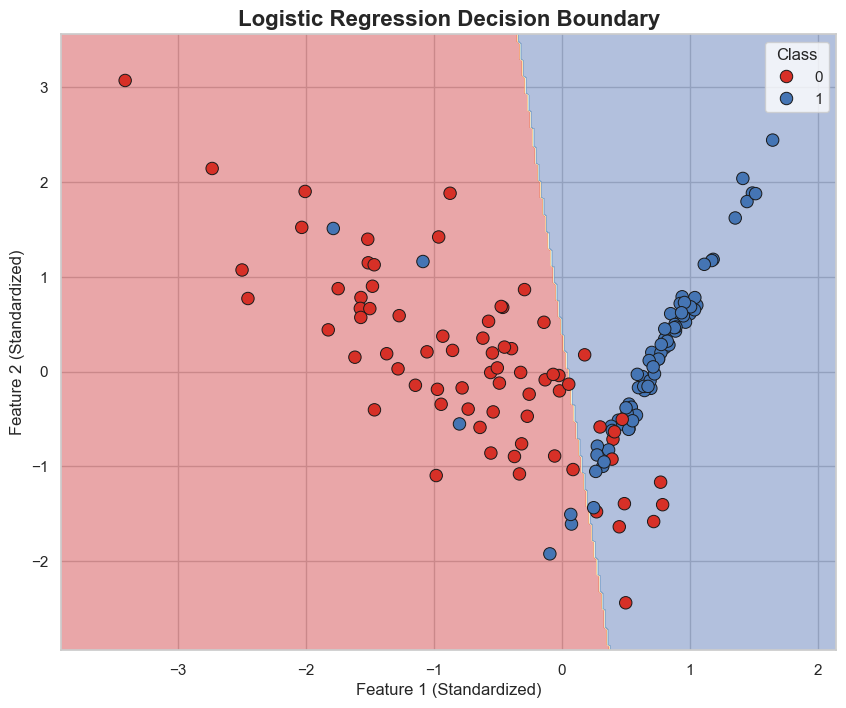

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

# Set a professional plot style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------
# 1. Data Generation and Preparation
# ---------------------------------------------------

# Generate a synthetic 2-feature dataset for easy visualization
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.05,
    random_state=42
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Data Preparation ---")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}\n")

# ---------------------------------------------------
# 2. Model Training
# ---------------------------------------------------

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("--- Model Training ---")
print("Model training complete.\n")

# ---------------------------------------------------
# 3. Model Evaluation
# ---------------------------------------------------

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Print the classification report
print("--- Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------
# 4. Visualizations
# ---------------------------------------------------

# Plot Confusion Matrix and ROC Curve side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Evaluation', fontsize=18, fontweight='bold')

# Plot Confusion Matrix
ax1.set_title('Confusion Matrix', fontsize=14)
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, cmap='Blues', ax=ax1, colorbar=False)

# Plot ROC Curve
ax2.set_title('ROC Curve', fontsize=14)
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax2, color='darkorange', lw=2)
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance Level (AUC = 0.5)')
ax2.legend()
plt.show()


# Plot Decision Boundary
# Create a meshgrid to plot the decision boundary
h = .02  # step size in the mesh
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict for each point in the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.4)

# Plot the test data points
sns.scatterplot(x=X_test_scaled[:, 0], y=X_test_scaled[:, 1], hue=y_test, palette=['#D73027', '#4575B4'], ec='k', s=80)

plt.title('Logistic Regression Decision Boundary', fontsize=16, fontweight='bold')
plt.xlabel('Feature 1 (Standardized)', fontsize=12)
plt.ylabel('Feature 2 (Standardized)', fontsize=12)
plt.legend(title='Class')
plt.show()

--- Data Preparation ---
Training set shape: (341, 30)
Validation set shape: (114, 30)
Test set shape: (114, 30)

--- Iterative Training ---
Epoch 20/100 | Train Acc: 0.9883 | Val Acc: 0.9912
Epoch 40/100 | Train Acc: 0.9883 | Val Acc: 0.9825
Epoch 60/100 | Train Acc: 0.9883 | Val Acc: 0.9825
Epoch 80/100 | Train Acc: 0.9883 | Val Acc: 0.9825
Epoch 100/100 | Train Acc: 0.9883 | Val Acc: 0.9825


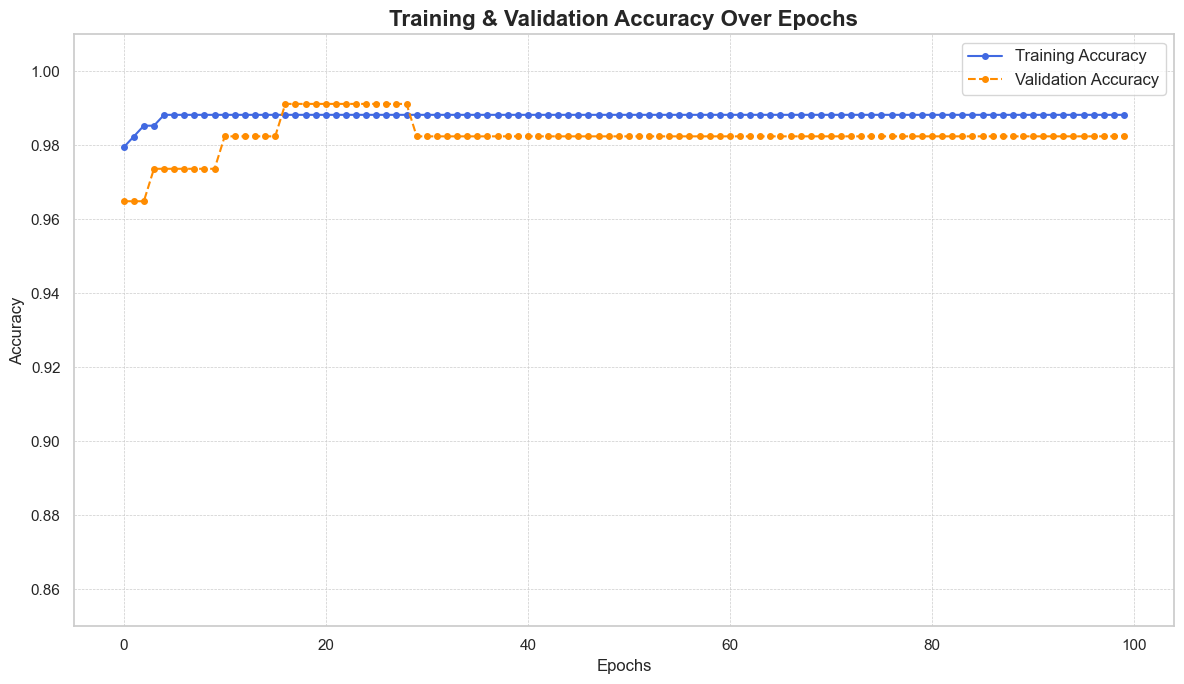


--- Final Evaluation on Unseen Test Set ---
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



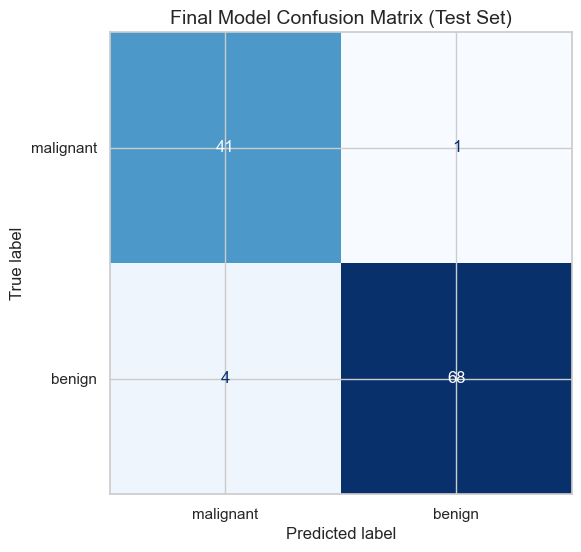

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Set a professional plot style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------
# 1. Load and Prepare the Dataset
# ---------------------------------------------------

# Load the dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split data into training (60%), validation (20%), and testing (20%)
# First split to separate out the test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split to create training (75% of 80% = 60%) and validation (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("--- Data Preparation ---")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}\n")


# ---------------------------------------------------
# 2. Iterative Model Training
# ---------------------------------------------------

# Use SGDClassifier with log_loss for logistic regression
model = SGDClassifier(loss='log_loss', random_state=42, eta0=0.01, learning_rate='constant')

n_epochs = 100
train_acc_history = []
val_acc_history = []
classes = np.unique(y_train)

print("--- Iterative Training ---")
for epoch in range(n_epochs):
    # Train for one epoch
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # Calculate accuracy on training set
    y_train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_acc_history.append(train_acc)

    # Calculate accuracy on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_acc_history.append(val_acc)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{n_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


# ---------------------------------------------------
# 3. Plot Training & Validation Accuracy
# ---------------------------------------------------

plt.figure(figsize=(12, 7))
plt.plot(train_acc_history, label='Training Accuracy', color='royalblue', marker='o', markersize=4, linestyle='-')
plt.plot(val_acc_history, label='Validation Accuracy', color='darkorange', marker='o', markersize=4, linestyle='--')
plt.title('Training & Validation Accuracy Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.85, 1.01) # Zoom in on the relevant accuracy range
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 4. Final Evaluation on Test Set
# ---------------------------------------------------

print("\n--- Final Evaluation on Unseen Test Set ---")
print(classification_report(y_test, model.predict(X_test_scaled), target_names=cancer.target_names))

# Plot confusion matrix for the final model on test data
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Final Model Confusion Matrix (Test Set)', fontsize=14)
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test,
    cmap='Blues',
    ax=ax,
    colorbar=False,
    display_labels=cancer.target_names
)
plt.show()